# 🎮 Video Game Sales — Unsupervised ML Lab
## Notebook 02 — Feature Engineering

**Mål med denna notebook:**
- Ladda det rengörda datasetet från notebook 01
- Skapa regionala försäljningsratios
- Gruppera plattformar i generationer
- Encoda kategoriska variabler
- Spara ett feature-engineerat dataset för klustring

---

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('../outputs/figures', exist_ok=True)

print('✅ Imports klara')

✅ Imports klara


## 1. Ladda data

Vi läser in det rengörda datasetet som sparades i slutet av notebook 01.

In [2]:
df = pd.read_csv('../data/vgsales_clean.csv')

print(f'Rader:    {len(df):,}')
print(f'Kolumner: {df.shape[1]}')
df.head()

Rader:    16,414
Kolumner: 17


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,User_Score_scaled
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E,80.0
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E,83.0
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E,80.0
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Regionala försäljningsratios

Istället för råa försäljningssiffror skapar vi **andelar per region** av global försäljning.  
Detta gör att vi kan jämföra spel oavsett hur stora de är totalt.

Exempel: Ett spel som säljer 90% i Japan är mer intressant än ett som säljer 10% — 
oavsett om det sålde 1M eller 10M totalt.

In [3]:
for region in ['NA', 'EU', 'JP', 'Other']:
    df[f'{region}_ratio'] = df[f'{region}_Sales'] / (df['Global_Sales'] + 1e-9)

# Kolla att de summerar till ~1
df['ratio_sum'] = df[['NA_ratio', 'EU_ratio', 'JP_ratio', 'Other_ratio']].sum(axis=1)

print('Ratio-kolumner skapade!')
print(f'\nKontroll — ratio_sum (ska vara ~1.0):')
print(df['ratio_sum'].describe().round(3))

df[['Name', 'NA_ratio', 'EU_ratio', 'JP_ratio', 'Other_ratio', 'ratio_sum']].head(8)

Ratio-kolumner skapade!

Kontroll — ratio_sum (ska vara ~1.0):
count    16414.000
mean         0.992
std          0.080
min          0.000
25%          1.000
50%          1.000
75%          1.000
max          2.000
Name: ratio_sum, dtype: float64


,Name,NA_ratio,EU_ratio,JP_ratio,Other_ratio,ratio_sum
0,Wii Sports,0.501151,0.350903,0.045680,0.102387,1.000121
1,Super Mario Bros.,0.722664,0.088966,0.169235,0.019135,1.000000
2,Mario Kart Wii,0.441441,0.359234,0.106700,0.092624,1.000000
3,Wii Sports Resort,0.476350,0.333537,0.100092,0.090021,1.000000
4,Pokemon Red/Pokemon Blue,0.359260,0.283392,0.325789,0.031878,1.000319
5,Tetris,0.766689,0.074686,0.139458,0.019167,1.000000
6,New Super Mario Bros.,0.378523,0.306711,0.218121,0.096644,1.000000
7,Wii Play,0.482711,0.317427,0.101314,0.098202,0.999654


### 🔍 Vad ser vi?

- **Tetris (NES):** 76% NA — extremt nordamerikanskt
- **Pokemon Red/Blue:** 33% JP — ovanligt högt för ett spel med global räckvidd
- **Mario Kart Wii:** Relativt jämnt fördelat — typiskt Nintendo global-hit
- **ratio_sum ≈ 1.0** ✅ — beräkningen stämmer

> 💡 Dessa ratios är kärn-features för Experiment 1 — K-Means klustring på regionala profiler.

---
## 3. Plattformsgenerationer

In [4]:
gen_map = {
    'NES': 'Retro', 'SNES': 'Retro', 'GB': 'Retro', 'GEN': 'Retro',
    '2600': 'Retro', 'GG': 'Retro', 'SCD': 'Retro', 'NG': 'Retro',
    'N64': '5th-gen', 'PS': '5th-gen', 'SAT': '5th-gen',
    'PS2': '6th-gen', 'GC': '6th-gen', 'XB': '6th-gen', 'GBA': '6th-gen',
    'PS3': '7th-gen', 'X360': '7th-gen', 'Wii': '7th-gen',
    'DS': '7th-gen', 'PSP': '7th-gen',
    'PS4': '8th-gen', 'XOne': '8th-gen', 'WiiU': '8th-gen', '3DS': '8th-gen',
    'PC': 'PC', 'PSV': 'Handheld',
}

df['Platform_Gen'] = df['Platform'].map(gen_map).fillna('Other')

print('Fördelning per plattformsgeneration:')
print(df['Platform_Gen'].value_counts())

Fördelning per plattformsgeneration:
Platform_Gen
7th-gen     7137
6th-gen     4258
5th-gen     1679
8th-gen     1299
PC           951
Retro        597
Handheld     429
Other         64
Name: count, dtype: int64


### 🔍 Plattformsgenerationer

| Generation | Plattformar | Antal spel |
|---|---|---|
| **7th-gen** | PS3, X360, Wii, DS, PSP | 7,137 — störst |
| **6th-gen** | PS2, GC, XB, GBA | 4,258 |
| **5th-gen** | N64, PS1, SAT | 1,679 |
| **8th-gen** | PS4, XOne, WiiU, 3DS | 1,299 — få pga datasetet slutar 2016 |
| **PC** | PC | 951 |
| **Retro** | NES, SNES, GB m.fl. | 597 |
| **Handheld** | PSVita | 429 |

> 💡 Vi använder generationer istället för enskilda plattformar för att minska  
> antalet kategorier från 31 → 7 — mycket bättre för klustring!

---
## 4. Encoda kategoriska variabler

In [5]:
# Genre encoding
df['Genre_encoded'] = df['Genre'].astype('category').cat.codes

# Platform_Gen encoding
df['Platform_Gen_encoded'] = df['Platform_Gen'].astype('category').cat.codes

# Visa mappning
genre_map = dict(enumerate(df['Genre'].astype('category').cat.categories))
gen_map_encoded = dict(enumerate(df['Platform_Gen'].astype('category').cat.categories))

print('Genre encoding:')
for k, v in genre_map.items():
    print(f'  {k} → {v}')

print('\nPlatform_Gen encoding:')
for k, v in gen_map_encoded.items():
    print(f'  {k} → {v}')

Genre encoding:
  0 → Action
  1 → Adventure
  2 → Fighting
  3 → Misc
  4 → Platform
  5 → Puzzle
  6 → Racing
  7 → Role-Playing
  8 → Shooter
  9 → Simulation
  10 → Sports
  11 → Strategy

Platform_Gen encoding:
  0 → 5th-gen
  1 → 6th-gen
  2 → 7th-gen
  3 → 8th-gen
  4 → Handheld
  5 → Other
  6 → PC
  7 → Retro


### 🔍 Notering om encoding

Vi använder **label encoding** (0, 1, 2...) vilket fungerar för trädbaserade modeller,  
men för K-Means kan det ge problem — algoritmen tolkar siffrorna som avstånd.

Exempel: `Strategy (11)` tolkas som "långt ifrån" `Action (0)` — men det stämmer inte logiskt.

**Lösning för klustring:** Vi använder Genre som filter/färg i visualiseringar  
snarare än som feature direkt i K-Means. I PCA kan vi inkludera den med försiktighet.

---
## 5. Era-kolumn

In [6]:
bins   = [1979, 1994, 2002, 2010, 2030]
labels = ['Retro (≤94)', '5th–6th gen (95–02)', '7th gen (03–10)', '8th gen (11+)']

df['Era'] = pd.cut(df['Year_of_Release'], bins=bins, labels=labels)

print('Fördelning per era:')
print(df['Era'].value_counts().sort_index())

Fördelning per era:
Era
Retro (≤94)             487
5th–6th gen (95–02)    3149
7th gen (03–10)        8759
8th gen (11+)          4019
Name: count, dtype: int64


### 🔍 Erafördelning

| Era | År | Antal spel |
|---|---|---|
| **Retro** | ≤1994 | 487 |
| **5th–6th gen** | 1995–2002 | 3,149 |
| **7th gen** | 2003–2010 | 8,759 — störst |
| **8th gen** | 2011+ | 4,019 — underskattat pga datasetet slutar 2016 |

> 💡 Era-kolumnen används i Experiment 3 för att färgkoda PCA-scatter —  
> kan algoritmen hitta dessa eror utan att titta på år?

---
## 6. Visualisera regionala ratios

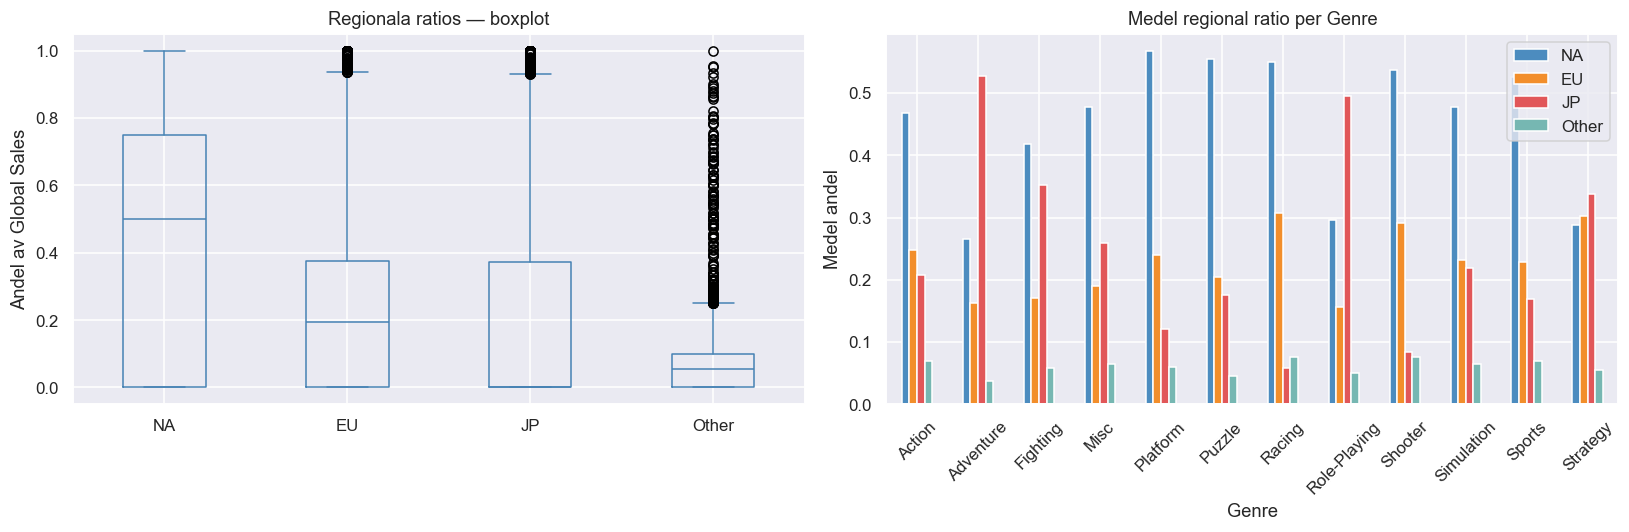

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot — ratio per region
ratio_cols = ['NA_ratio', 'EU_ratio', 'JP_ratio', 'Other_ratio']
df[ratio_cols].plot(kind='box', ax=axes[0], color='steelblue')
axes[0].set_title('Regionala ratios — boxplot')
axes[0].set_ylabel('Andel av Global Sales')
axes[0].set_xticklabels(['NA', 'EU', 'JP', 'Other'])

# Medel-ratio per genre
genre_ratios = df.groupby('Genre')[ratio_cols].mean()
genre_ratios.plot(kind='bar', ax=axes[1],
                  color=['#4c8cbf', '#f28e2b', '#e15759', '#76b7b2'],
                  edgecolor='white')
axes[1].set_title('Medel regional ratio per Genre')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Medel andel')
axes[1].legend(['NA', 'EU', 'JP', 'Other'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/09_regional_ratios.png', bbox_inches='tight', dpi=150)
plt.show()

### 🔍 Vad ser vi?

| Observation | Detalj |
|---|---|
| **NA boxplot bred** | Stor variation — NA-andelen kan vara allt från 0% till 100% |
| **JP har massor av outliers** | De flesta spel säljer lite i JP, men vissa säljer nästan bara där |
| **Adventure = Japans genre** | ~52% JP-ratio i snitt — extremt kulturspecifikt |
| **Platform & Puzzle** | Nästan helt NA-dominerat |
| **Role-Playing** | Jämnt NA/JP-split — RPG är global men Japan-rotat |
| **Strategy** | Hög JP-ratio — strategispel populära i Japan |

> 💡 Dessa mönster är precis vad K-Means i Experiment 1 kommer att klustra på!  
> Adventure och Role-Playing borde hamna i ett Japan-kluster.

---
## 7. Spara feature-engineerat dataset

In [8]:
# Droppa hjälpkolumnen ratio_sum
df.drop(columns=['ratio_sum'], inplace=True)

df.to_csv('../data/vgsales_features.csv', index=False)
print(f'✅ Sparat vgsales_features.csv ({len(df):,} rader, {df.shape[1]} kolumner)')
print(f'\nNya kolumner tillagda:')
new_cols = ['NA_ratio', 'EU_ratio', 'JP_ratio', 'Other_ratio',
            'Platform_Gen', 'Platform_Gen_encoded', 'Genre_encoded', 'Era']
for col in new_cols:
    print(f'  + {col}')

✅ Sparat vgsales_features.csv (16,414 rader, 25 kolumner)

Nya kolumner tillagda:
  + NA_ratio
  + EU_ratio
  + JP_ratio
  + Other_ratio
  + Platform_Gen
  + Platform_Gen_encoded
  + Genre_encoded
  + Era


## 8. Sammanfattning & Nästa steg

### Vad vi skapade:

| Feature | Beskrivning | Används i |
|---|---|---|
| `NA/EU/JP/Other_ratio` | Andel av global försäljning per region | Experiment 1, 3 |
| `Platform_Gen` | Plattformsgeneration (7th-gen etc.) | Experiment 3 |
| `Platform_Gen_encoded` | Numerisk encoding av generation | Klustring |
| `Genre_encoded` | Numerisk encoding av genre | PCA |
| `Era` | Tidsepok baserad på utgivningsår | Experiment 3 visualisering |

### Nästa steg:
➡️ `03_clustering.ipynb` — K-Means, Hierarkisk klustring och PCA